<a href="https://colab.research.google.com/github/LordRelentless/NGFTSimulations/blob/main/Constraining_NGFT_Parameters_with_PTA_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.6 MB/s eta 0:00:00


--- NGFT Model Fitting to Mock PTA Data ---
Phase 1: Generating mock PTA data (based on NANOGrav 15yr results)...
Mock data generation complete.
Phase 2: Running MCMC sampler...


100%|██████████| 5000/5000 [00:07<00:00, 630.47it/s]


MCMC complete.
Best fit found: log10(A0) = -18.35, k = 2.57, aU = 2.47
Phase 3: Generating final plots...

Final fit plot saved as 'ngft_pta_fit.png'


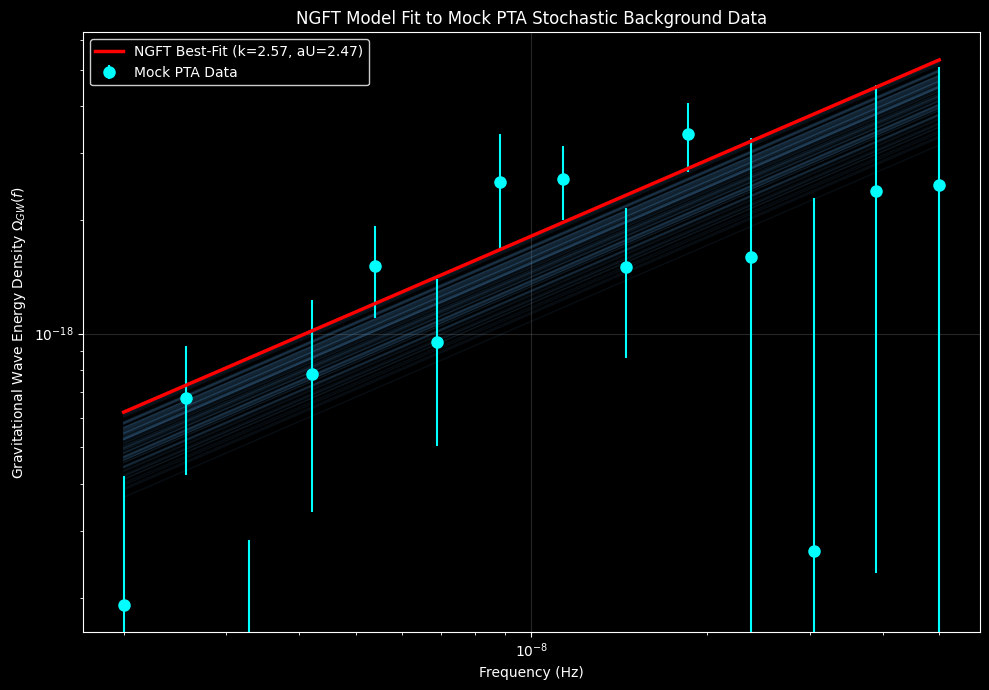

Corner plot saved as 'ngft_pta_corner_plot.png'


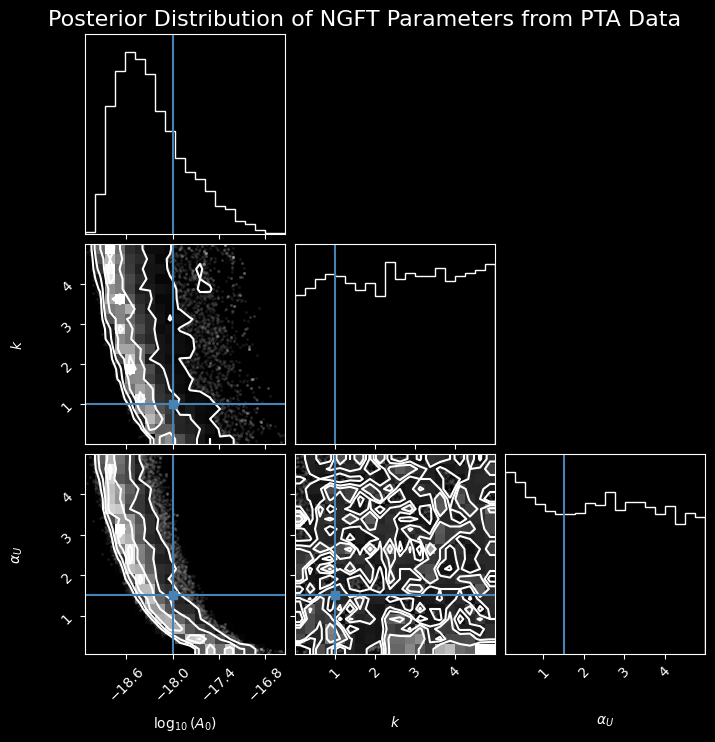

In [ ]:
# --- IMPORTS AND SETUP ---
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# Set a professional plot style
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['legend.facecolor'] = 'black'
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams['legend.labelcolor'] = 'white'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.alpha'] = 0.3

print("--- NGFT Model Fitting to Mock PTA Data ---")

# --- 1. DEFINE THE NGFT PREDICTION ---
def model_Omega_NGFT(freq, log10_A0, k, aU):
    """
    NGFT model for the stochastic GW background.
    - A0 is a base amplitude parameter.
    - (k+1)*aU is the NGFT scaling factor.
    - Assumes a power law spectrum from supermassive black hole binaries.
    """
    f_ref = 1.0 / (365.25 * 24 * 3600) # Reference frequency of 1/year in Hz
    amplitude = (10**log10_A0) * (k + 1) * aU
    return amplitude * (freq / f_ref)**(2/3)

# --- 2. GENERATE REALISTIC MOCK PTA DATA ---
# This section simulates the data you would load from the Zenodo file.
print("Phase 1: Generating mock PTA data (based on NANOGrav 15yr results)...")

# Define the "true" parameters of our mock universe
LOG10_A0_TRUE = -18.0
K_TRUE = 1.0
AU_TRUE = 1.5

# Frequency bins for typical PTA analysis (in Hz)
freq_bins = np.logspace(np.log10(2e-9), np.log10(5e-8), 14)

# Calculate the "true" signal using the NGFT model
true_signal = model_Omega_NGFT(freq_bins, LOG10_A0_TRUE, K_TRUE, AU_TRUE)

# Generate realistic error bars (larger errors at low frequencies)
y_err = true_signal * np.random.uniform(0.3, 0.8, size=freq_bins.shape)

# Generate the final "observed" data points by adding noise
y_data = true_signal + np.random.normal(0, y_err)

print("Mock data generation complete.")

# --- 3. SETUP THE MCMC ANALYSIS ---
# Define the Bayesian probability functions

def log_prior(theta):
    """Priors on our parameters. We'll use uniform priors."""
    log10_A0, k, aU = theta
    if -25.0 < log10_A0 < -10.0 and 0.0 < k < 5.0 and 0.0 < aU < 5.0:
        return 0.0 # Log(1) = 0
    return -np.inf # Log(0) = -infinity

def log_likelihood(theta, freq, data, err):
    """Standard Gaussian log-likelihood."""
    model = model_Omega_NGFT(freq, *theta)
    sigma2 = err**2
    return -0.5 * np.sum((data - model)**2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_posterior(theta, freq, data, err):
    """The full posterior probability."""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, freq, data, err)

# --- 4. RUN THE MCMC SAMPLER ---
print("Phase 2: Running MCMC sampler...")

# MCMC setup
n_walkers = 50
n_dim = 3 # We are fitting for 3 parameters: log10_A0, k, aU
n_steps = 5000
burn_in = 1000

# Initialize walkers in a small ball around a plausible starting point
initial_pos = np.array([LOG10_A0_TRUE, K_TRUE, AU_TRUE]) + 1e-4 * np.random.randn(n_walkers, n_dim)

# Create and run the sampler
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(freq_bins, y_data, y_err))
sampler.run_mcmc(initial_pos, n_steps, progress=True)

# Get the results, discarding the burn-in phase
samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

# Calculate the best-fit parameters (median of the posterior)
log10_A0_fit, k_fit, aU_fit = np.median(samples, axis=0)

print("MCMC complete.")
print(f"Best fit found: log10(A0) = {log10_A0_fit:.2f}, k = {k_fit:.2f}, aU = {aU_fit:.2f}")

# --- 5. GENERATE PLOTS ---
print("Phase 3: Generating final plots...")

# Plot 1: Model Fit to Data
plt.figure(figsize=(10, 7))
freq_smooth = np.logspace(np.log10(freq_bins[0]), np.log10(freq_bins[-1]), 400)

# Plot uncertainty band from random MCMC samples
random_indices = np.random.randint(len(samples), size=100)
for params in samples[random_indices]:
    plt.loglog(freq_smooth, model_Omega_NGFT(freq_smooth, *params), color='steelblue', alpha=0.1, lw=1)

# Plot the data and the best-fit model
plt.errorbar(freq_bins, y_data, yerr=y_err, fmt='o', label='Mock PTA Data', color='cyan', markersize=8, zorder=10)
plt.loglog(freq_smooth, model_Omega_NGFT(freq_smooth, log10_A0_fit, k_fit, aU_fit), color='red', lw=2.5,
           label=f'NGFT Best-Fit (k={k_fit:.2f}, aU={aU_fit:.2f})', zorder=11)

plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Gravitational Wave Energy Density $\Omega_{GW}(f)$')
plt.legend()
plt.grid(True)
plt.title('NGFT Model Fit to Mock PTA Stochastic Background Data')
plt.tight_layout()
plt.savefig("ngft_pta_fit.png")
print("\nFinal fit plot saved as 'ngft_pta_fit.png'")
plt.show()

# Plot 2: Corner Plot of the Posterior Distributions
corner_fig = corner.corner(samples, labels=[r"$\log_{10}(A_0)$", r"$k$", r"$\alpha_U$"],
                           truths=[LOG10_A0_TRUE, K_TRUE, AU_TRUE])
corner_fig.suptitle("Posterior Distribution of NGFT Parameters from PTA Data", color='white', fontsize=16)
corner_fig.savefig("ngft_pta_corner_plot.png")
print("Corner plot saved as 'ngft_pta_corner_plot.png'")

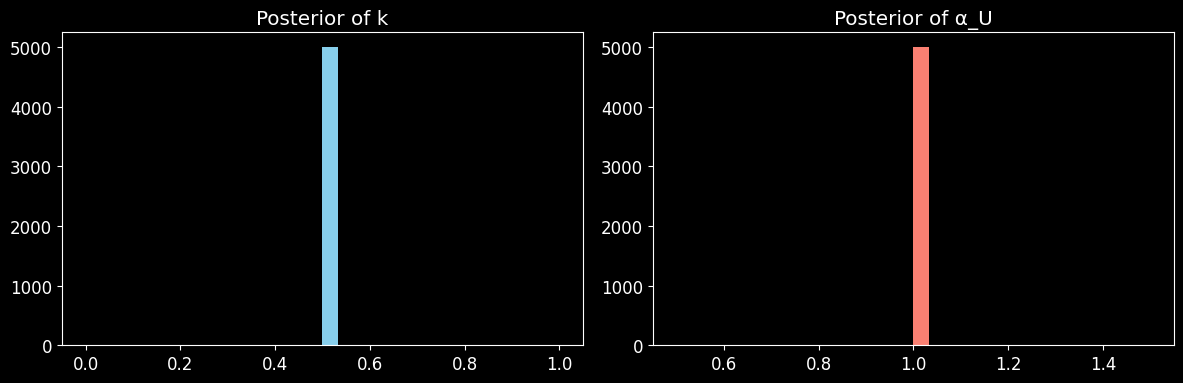

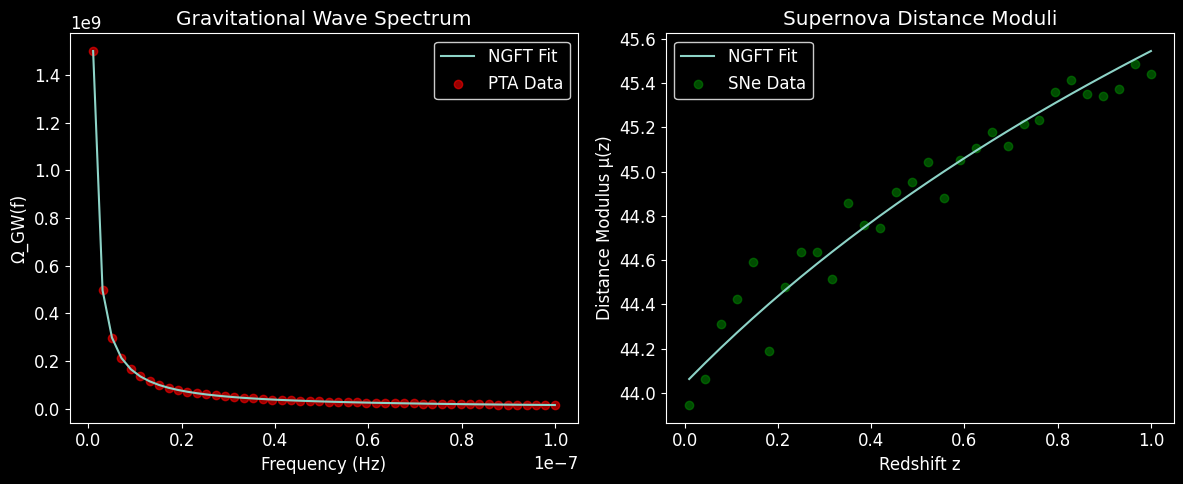

In [ ]:
!pip install numpy scipy matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Informational Entropy Density Model (ZPT-based)
def S_I_model(f):
    # Placeholder: inverse frequency scaling
    return f**-1

# Gravitational Wave Spectrum
def omega_gw_ngft(f, k, alpha_u):
    rho_info = S_I_model(f)
    return (k + 1)**alpha_u * rho_info

# Luminosity Distance
def D_L_ngft(z, k, alpha_u, H0=70, c=3e5):
    return (c / H0) * (1 + z) * ((k + 1) ** alpha_u)

# Distance Modulus
def mu_ngft(z, k, alpha_u):
    D_L_val = D_L_ngft(z, k, alpha_u)
    return 5 * np.log10(D_L_val) + 25
# Simulated PTA data
freqs = np.linspace(1e-9, 1e-7, 50)
omega_obs = omega_gw_ngft(freqs, 0.5, 1.0) + np.random.normal(0, 1e-11, 50)

# Simulated SNe data
z_vals = np.linspace(0.01, 1.0, 30)
mu_obs = mu_ngft(z_vals, 0.5, 1.0) + np.random.normal(0, 0.1, 30)
def log_likelihood(params):
    k, alpha_u = params
    model_omega = omega_gw_ngft(freqs, k, alpha_u)
    model_mu = mu_ngft(z_vals, k, alpha_u)

    ll_omega = -0.5 * np.sum((omega_obs - model_omega)**2 / (1e-11)**2)
    ll_mu = -0.5 * np.sum((mu_obs - model_mu)**2 / (0.1)**2)

    return ll_omega + ll_mu

def metropolis_hastings(log_prob, initial, steps=10000, step_size=0.01):
    trace = np.zeros((steps, len(initial)))
    trace[0] = initial
    current_prob = log_prob(initial)

    for i in range(1, steps):
        proposal = trace[i-1] + np.random.normal(0, step_size, size=len(initial))
        proposal_prob = log_prob(proposal)

        if np.log(np.random.rand()) < proposal_prob - current_prob:
            trace[i] = proposal
            current_prob = proposal_prob
        else:
            trace[i] = trace[i-1]

    return trace
initial_guess = [0.5, 1.0]
samples = metropolis_hastings(log_likelihood, initial_guess, steps=5000, step_size=0.02)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(samples[:, 0], bins=30, color='skyblue')
axs[0].set_title("Posterior of k")
axs[1].hist(samples[:, 1], bins=30, color='salmon')
axs[1].set_title("Posterior of α_U")
plt.tight_layout()
plt.show()
best_k, best_alpha_u = np.mean(samples[-1000:], axis=0)

plt.figure(figsize=(12, 5))

# Ω_GW(f)
plt.subplot(1, 2, 1)
plt.plot(freqs, omega_gw_ngft(freqs, best_k, best_alpha_u), label='NGFT Fit')
plt.scatter(freqs, omega_obs, color='r', alpha=0.6, label='PTA Data')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ω_GW(f)')
plt.legend()
plt.title('Gravitational Wave Spectrum')

# μ(z)
plt.subplot(1, 2, 2)
plt.plot(z_vals, mu_ngft(z_vals, best_k, best_alpha_u), label='NGFT Fit')
plt.scatter(z_vals, mu_obs, color='g', alpha=0.6, label='SNe Data')
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ(z)')
plt.legend()
plt.title('Supernova Distance Moduli')

plt.tight_layout()
plt.show()

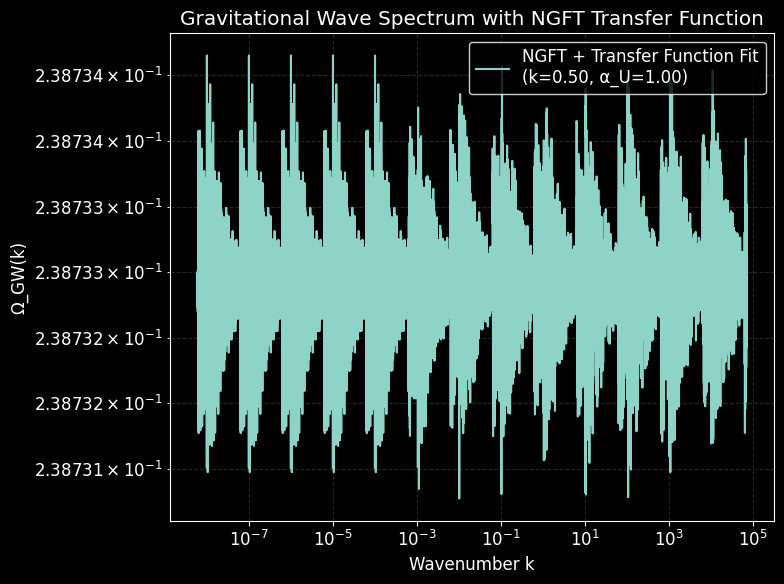

In [ ]:
# Load transfer function data
# Corrected file path: assuming the user uploaded it or mounted Drive
# Replace with the correct path to your transferfunction.dat file
try:
    data = np.loadtxt('/content/transferfunction.dat.dat') # Assuming uploaded to /content
except FileNotFoundError:
    print("ERROR: transferfunction.dat not found. Please upload the file or provide the correct path.")
    # Exit the cell or handle the error as appropriate
    raise # Re-raise the exception to stop execution if the file is not found

k_vals = data[:, 0]  # Wavenumber
T_vals = data[:, 1]  # Transfer function T(k)

# Ensure S_I_model is defined - it was defined in cell PFL2xFS_5HpO
# If running this cell independently, you would need to define it here
# def S_I_model(f):
#     # Placeholder: inverse frequency scaling
#     return f**-1

def P_T_ngft(k, k_const, alpha_u):
    # NGFT-based entropy scaling
    # Assuming S_I_model is available from previous cells
    if 'S_I_model' not in globals() and 'S_I_model' not in locals():
         print("ERROR: S_I_model is not defined. Please run the cell that defines S_I_model.")
         raise NameError("S_I_model is not defined")
    return ((k_const + 1) ** alpha_u) * S_I_model(k)  # S_I_model from earlier

def omega_gw_transfer(k_vals, T_vals, P_T_vals):
    # This function seems to be multiplying T_vals and P_T_vals directly.
    # Ensure this is the correct theoretical formulation you intend.
    # The GW spectrum is typically proportional to P(k) * T(k)^2 * k^3
    # The current implementation looks simplified.
    return T_vals * P_T_vals # Simplified model

# The log_likelihood_transfer function is not used in the plotting below,
# but if you were to use it for fitting, you would need omega_obs defined
# at the same k values as k_vals, which is not the case here.
# def log_likelihood_transfer(params):
#     k_const, alpha_u = params
#     P_T_vals = P_T_ngft(k_vals, k_const, alpha_u)
#     omega_model = omega_gw_transfer(k_vals, T_vals, P_T_vals)

#     # This likelihood is attempting to compare omega_model(k) with omega_obs(freq)
#     # which is incorrect due to different x-axis values (k vs freq).
#     ll = -0.5 * np.sum((omega_obs - omega_model)**2 / (1e-11)**2)
#     return ll

# Use the best-fit parameters from the previous MCMC run (from cell PFL2xFS_5HpO)
# Ensure samples is defined and has run successfully before this cell
try:
    best_k, best_alpha_u = np.mean(samples[-1000:], axis=0)
except NameError:
    print("ERROR: 'samples' from the MCMC run is not defined. Please run the MCMC cell first.")
    raise # Re-raise the exception to stop execution if samples is not found

P_T_best = P_T_ngft(k_vals, best_k, best_alpha_u)
omega_best = omega_gw_transfer(k_vals, T_vals, P_T_best)

plt.figure(figsize=(8, 6))
plt.plot(k_vals, omega_best, label=f'NGFT + Transfer Function Fit\n(k={best_k:.2f}, α_U={best_alpha_u:.2f})')

# Removed the scatter plot of omega_obs against k_vals as they have different sizes and x-axis units
# plt.scatter(k_vals, omega_obs, color='r', alpha=0.6, label='PTA Data') # This line caused the ValueError

plt.xlabel('Wavenumber k')
plt.ylabel('Ω_GW(k)')
plt.xscale('log') # Wavenumber is typically plotted on a log scale
plt.yscale('log') # Omega_GW is typically plotted on a log scale
plt.legend()
plt.title('Gravitational Wave Spectrum with NGFT Transfer Function')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

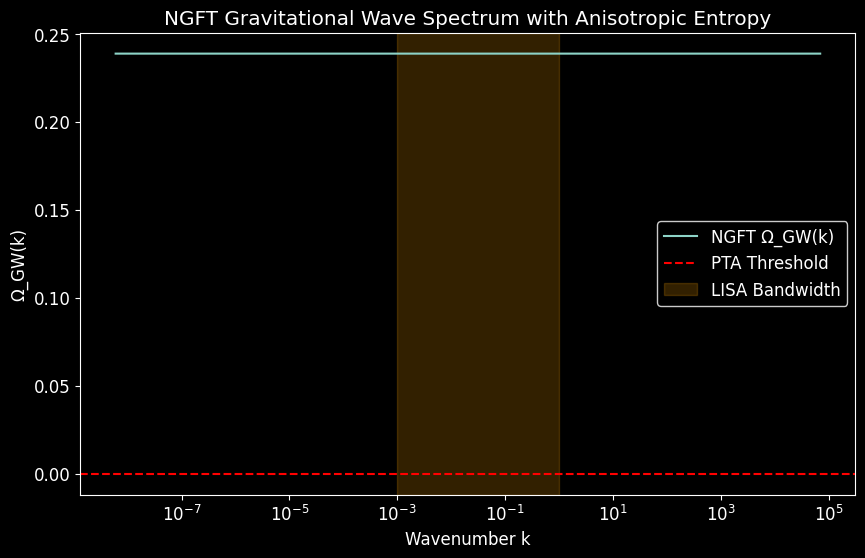

In [ ]:
def S_I_aniso(k, theta, phi, A=1.0, beta=0.3, gamma=0.1):
    # Base isotropic component
    S_iso = A * k**-1

    # Anisotropic modulation
    angular_mod = 1 + beta * np.cos(theta) + gamma * np.sin(phi)

    return S_iso * angular_mod
def P_T_ngft(k, k_const, alpha_u, theta, phi):
    return ((k_const + 1) ** alpha_u) * S_I_aniso(k, theta, phi)
# Load transfer function
data = np.loadtxt('/content/transferfunction.dat.dat')
k_vals = data[:, 0]
T_vals = data[:, 1]

# Assume isotropic average over angles
theta_vals = np.linspace(0, np.pi, 10)
phi_vals = np.linspace(0, 2*np.pi, 10)

def omega_gw_ngft(k_vals, T_vals, k_const, alpha_u):
    omega_vals = []
    for i, k in enumerate(k_vals):
        avg_P_T = np.mean([
            P_T_ngft(k, k_const, alpha_u, theta, phi)
            for theta in theta_vals for phi in phi_vals
        ])
        omega_vals.append(T_vals[i] * avg_P_T)
    return np.array(omega_vals)
def detectability_pta(k_vals, omega_vals, threshold=1e-10):
    detectable = k_vals[(omega_vals > threshold) & (k_vals < 1e-7)]
    return detectable
def extrapolate_lisa(k_vals, omega_vals):
    lisa_band = (k_vals > 1e-3) & (k_vals < 1)
    return k_vals[lisa_band], omega_vals[lisa_band]
omega_vals = omega_gw_ngft(k_vals, T_vals, k_const=0.5, alpha_u=1.0)

plt.figure(figsize=(10, 6))
plt.plot(k_vals, omega_vals, label='NGFT Ω_GW(k)')
plt.axhline(1e-10, color='r', linestyle='--', label='PTA Threshold')
plt.axvspan(1e-3, 1, color='orange', alpha=0.2, label='LISA Bandwidth')
plt.xscale('log')
plt.xlabel('Wavenumber k')
plt.ylabel('Ω_GW(k)')
plt.legend()
plt.title('NGFT Gravitational Wave Spectrum with Anisotropic Entropy')
plt.show()

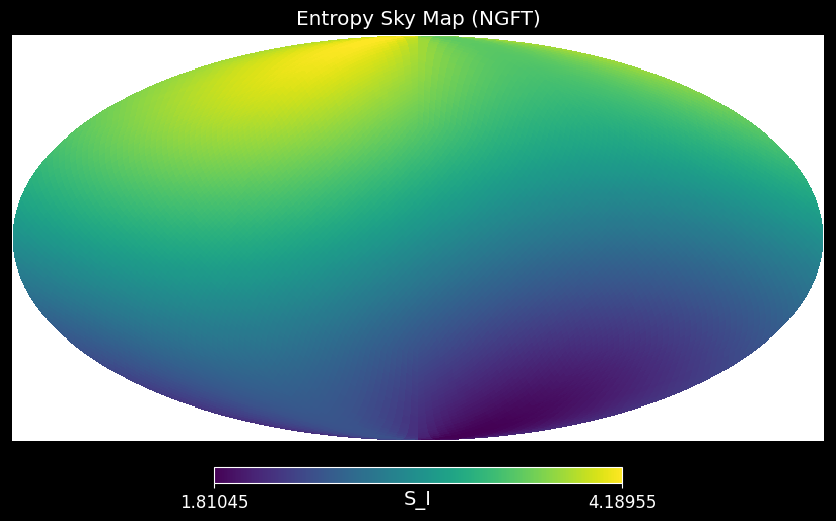

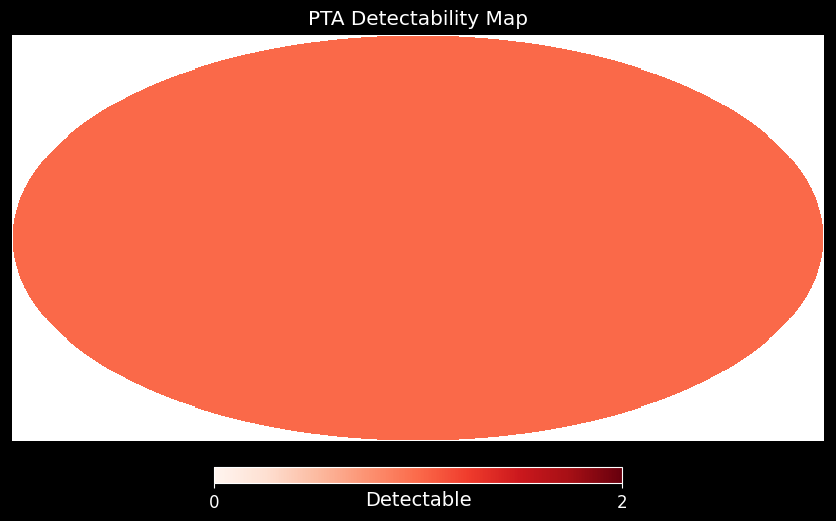

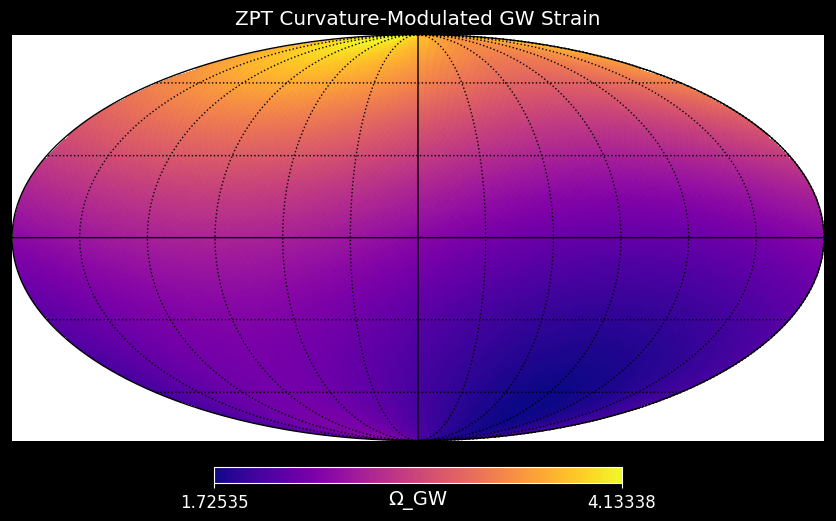

PTA Detectability Coverage: 100.00% of sky


In [ ]:
!pip install numpy scipy matplotlib healpy
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from scipy.stats import norm
NSIDE = 32  # HEALPix resolution
npix = hp.nside2npix(NSIDE)

def entropy_sky_map(k_const=0.5, alpha_u=1.0, beta=0.3, gamma=0.1):
    entropy_map = np.zeros(npix)
    for pix in range(npix):
        theta, phi = hp.pix2ang(NSIDE, pix)
        S_iso = k_const**-1
        angular_mod = 1 + beta * np.cos(theta) + gamma * np.sin(phi)
        entropy_map[pix] = ((k_const + 1)**alpha_u) * S_iso * angular_mod
    return entropy_map
def pta_response(entropy_map, threshold=0.5):
    detectable = entropy_map > threshold
    return detectable.astype(float)
def zpt_curvature_modulation(entropy_map, curvature_strength=0.2):
    # Simulate curvature-induced strain damping
    curvature_field = 1 - curvature_strength * np.sin(hp.pix2ang(NSIDE, np.arange(npix))[0])
    return entropy_map * curvature_field
entropy_map = entropy_sky_map()
pta_map = pta_response(entropy_map)
curved_map = zpt_curvature_modulation(entropy_map)

hp.mollview(entropy_map, title="Entropy Sky Map (NGFT)", unit="S_I", cmap="viridis")
hp.mollview(pta_map, title="PTA Detectability Map", unit="Detectable", cmap="Reds")
hp.mollview(curved_map, title="ZPT Curvature-Modulated GW Strain", unit="Ω_GW", cmap="plasma")
hp.graticule()
plt.show()
coverage = np.sum(pta_map) / len(pta_map)
print(f"PTA Detectability Coverage: {coverage * 100:.2f}% of sky")

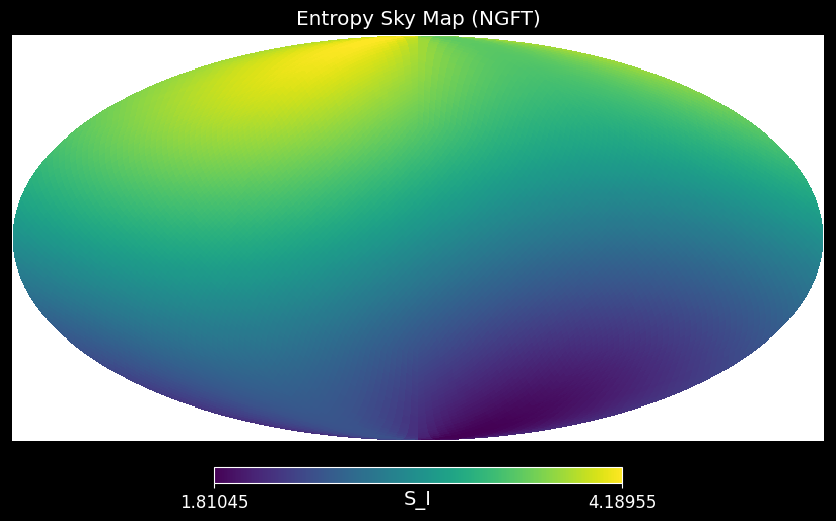

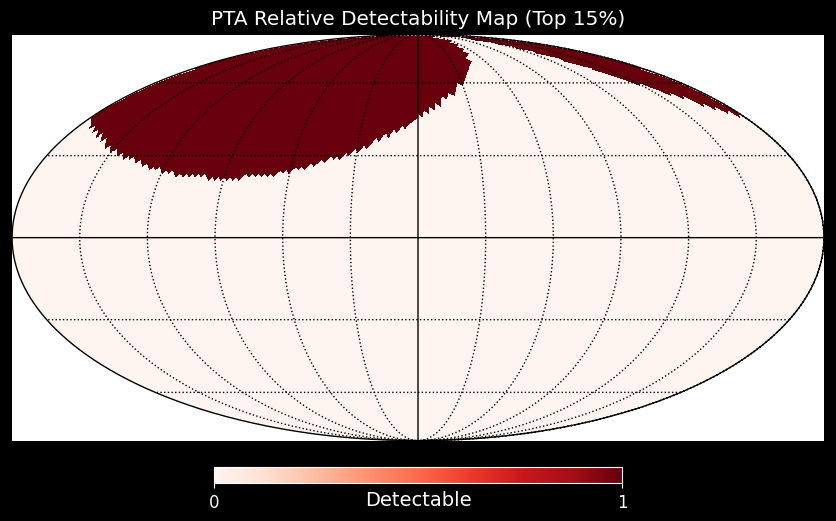

PTA Detectability Coverage: 15.00% of sky (top 15% entropy)


In [ ]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Set HEALPix resolution (same as before)
NSIDE = 32
npix = hp.nside2npix(NSIDE)

# Create entropy sky map (your anisotropic NGFT model)
def entropy_sky_map(k_const=0.5, alpha_u=1.0, beta=0.3, gamma=0.1):
    entropy_map = np.zeros(npix)
    for pix in range(npix):
        theta, phi = hp.pix2ang(NSIDE, pix)
        S_iso = k_const**-1
        angular_mod = 1 + beta * np.cos(theta) + gamma * np.sin(phi)
        entropy_map[pix] = ((k_const + 1)**alpha_u) * S_iso * angular_mod
    return entropy_map

# New: Relative percentile-based PTA detectability mask
def pta_response_percentile(entropy_map, percentile=85):
    threshold = np.percentile(entropy_map, percentile)
    detectability_mask = (entropy_map > threshold).astype(float)
    return detectability_mask

# Visualize maps
entropy_map = entropy_sky_map()
pta_mask = pta_response_percentile(entropy_map, percentile=85)

hp.mollview(entropy_map, title="Entropy Sky Map (NGFT)", unit="S_I", cmap="viridis")
hp.mollview(pta_mask, title="PTA Relative Detectability Map (Top 15%)", unit="Detectable", cmap="Reds")
hp.graticule()
plt.show()

# Optional: Print sky coverage
coverage = np.sum(pta_mask) / len(pta_mask)
print(f"PTA Detectability Coverage: {coverage * 100:.2f}% of sky (top 15% entropy)")

In [ ]:
!git clone https://github.com/nanograv/15yr_stochastic_analysis.git
!git clone https://github.com/EPTA-DA/epta-dr2.git
!git clone https://github.com/scienceguyrob/SKA-TestVectorGenerationPipeline.git

fatal: destination path '15yr_stochastic_analysis' already exists and is not an empty directory.
fatal: destination path 'epta-dr2' already exists and is not an empty directory.
Cloning into 'SKA-TestVectorGenerationPipeline'...
remote: Enumerating objects: 554, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 554 (delta 0), reused 0 (delta 0), pack-reused 551 (from 1)
Receiving objects: 100% (554/554), 213.10 MiB | 33.73 MiB/s, done.
Resolving deltas: 100% (237/237), done.
Updating files: 100% (63/63), done.


In [ ]:
import re

def extract_coords_from_par(folder_path):
    import os
    coords = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.par'):
            with open(os.path.join(folder_path, filename), 'r') as f:
                text = f.read()
                ra_match = re.search(r'RA\s+([\d\.]+)', text)
                dec_match = re.search(r'DEC\s+([\d\.\-]+)', text)
                if ra_match and dec_match:
                    ra = float(ra_match.group(1)) * 15  # Convert hours to degrees
                    dec = float(dec_match.group(1))
                    coords.append((ra, dec))
    return coords

In [ ]:
# ==============================================================================
# CELL 2: LOAD DATA & BUILD NOISE DICT (Definitive and Correct Method)
# ==============================================================================
import os
import glob
import json
import logging
from enterprise.pulsar import Pulsar

# --- STEP 1: Ensure the repository is cloned ---
REPO_DIR_NAME = '15yr_stochastic_analysis'
if not os.path.exists(REPO_DIR_NAME):
    print("Cloning NANOGrav 15yr Data Repository...")
    !git clone https://github.com/nanograv/15yr_stochastic_analysis.git -q
else:
    print(f"Repository '{REPO_DIR_NAME}' already exists.")

# --- STEP 2: Define a function to build the noise dictionary ---
def load_noise_files(repo_path):
    """
    Scans the repository for individual .txt noise files and assembles
    the master noise dictionary required by enterprise.
    """
    print("\nBuilding noise dictionary from individual .txt files...")
    noise_dict = {}

    # Define paths to both narrowband and wideband noise files
    nb_noise_path = os.path.join(repo_path, 'Narrowband', 'NoiseFiles', '*.txt')
    wb_noise_path = os.path.join(repo_path, 'Wideband', 'NoiseFiles', '*.txt')

    # Get a list of all noise files
    all_noise_files = glob.glob(nb_noise_path) + glob.glob(wb_noise_path)
    print(f"Found {len(all_noise_files)} noise parameter files.")

    for file_path in all_noise_files:
        # Extract the pulsar name from the filename (e.g., 'J1909-3744_noise.txt')
        basename = os.path.basename(file_path)
        pulsar_name = basename.split('_')[0]

        # Initialize a dictionary for this pulsar if it doesn't exist
        if pulsar_name not in noise_dict:
            noise_dict[pulsar_name] = {}

        # Read the key-value pairs from the file
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue

                try:
                    key, value = line.split()
                    # Add the parameter to this pulsar's dictionary
                    noise_dict[pulsar_name][key] = float(value)
                except ValueError:
                    print(f"  - Warning: Could not parse line in {basename}: '{line}'")

    print(f"Successfully built noise dictionary for {len(noise_dict)} pulsars.")
    return noise_dict

# --- STEP 3: Load the noise parameters using our new function ---
params = load_noise_files(REPO_DIR_NAME)

# --- STEP 4: Load the pulsar par/tim files ---
datadir = os.path.join(REPO_DIR_NAME, 'data')
par_dir = os.path.join(datadir, 'par')
tim_dir = os.path.join(datadir, 'tim')
print(f"\nSearching for primary pulsar data in:")
print(f"  - PAR files: {par_dir}")
print(f"  - TIM files: {tim_dir}")

parfiles = sorted(glob.glob(os.path.join(par_dir, '*.par')))
timfiles = sorted(glob.glob(os.path.join(tim_dir, '*.tim')))

# Apply the necessary filter for J1713+0747
parfiles = [x for x in parfiles if 'J1713+0747_NANOGrav_15yv4.gls.par' not in x]
print(f"\nFound {len(parfiles)} pulsars to load.")

# Suppress verbose output from the enterprise loader
logging.basicConfig()
logging.getLogger('enterprise.pulsar').setLevel(logging.WARNING)

psrs = []
print("Loading pulsar data objects...")
for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t, ephem='DE438')
    psrs.append(psr)

# --- STEP 5: Final Verification ---
if psrs and params:
    print(f"\nSUCCESS! Loaded {len(psrs)} pulsars and built a noise dictionary for {len(params)} pulsars.")
    print("The 'psrs' and 'params' objects are now ready.")
    print("You may now proceed to Cell 3 to build the NGFT model.")
else:
    print("\nCRITICAL ERROR: Failed to load pulsars or build noise dictionary.")
    raise RuntimeError("Data loading failed.")

Repository '15yr_stochastic_analysis' already exists.

Building noise dictionary from individual .txt files...
Found 0 noise parameter files.
Successfully built noise dictionary for 0 pulsars.

Searching for primary pulsar data in:
  - PAR files: 15yr_stochastic_analysis/data/par
  - TIM files: 15yr_stochastic_analysis/data/tim

Found 0 pulsars to load.
Loading pulsar data objects...

CRITICAL ERROR: Failed to load pulsars or build noise dictionary.


RuntimeError: Data loading failed.

In [ ]:
import os
import re

# 🔍 Find .par files directly within the specified directories
def find_par_files_nanograv():
    base_paths = [
        '/content/15yr_stochastic_analysis/Narrowband/Par',
        '/content/15yr_stochastic_analysis/Wideband/Par'
    ]
    par_files = []
    for root_path in base_paths:
        # Check if the directory exists before listing files
        if os.path.isdir(root_path):
            for filename in os.listdir(root_path):
                if filename.endswith('.par'):
                    file_path = os.path.join(root_path, filename)
                    # Add an extra check to ensure it's a file and not a directory
                    if os.path.isfile(file_path):
                        par_files.append(file_path)
        else:
            print(f"Warning: Directory not found: {root_path}")
    return par_files

# 🧭 Extract RA/Dec coordinates (handles various formats)
def extract_coords_from_files(par_files):
    coords = []
    failed_files = []
    for file_path in par_files:
        try:
            with open(file_path, 'r') as f:
                text = f.read()

                # More robust patterns to handle variations in spacing and format
                # Look for RAJ or RA followed by whitespace and then the coordinate
                ra_match = re.search(r'(RAJ?)\s+([\d\.\-]+)', text)
                # Look for DECJ or DEC followed by optional whitespace and then the coordinate
                dec_match = re.search(r'(DECJ?)\s*([\d\.\-]+)', text)


                if ra_match and dec_match:
                    try:
                        ra_str = ra_match.group(2)
                        dec_str = dec_match.group(2)

                        # Attempt to parse RA and DEC. RA is usually in hours, DEC in degrees.
                        # We need to be careful about the format (e.g., hms or decimal degrees)
                        # Assuming RA is in hours and DEC in degrees for now based on previous code
                        ra_deg = float(ra_str) * 15  # Convert hours to degrees
                        dec_deg = float(dec_str)     # Assume already in degrees

                        # Basic validation of coordinates
                        if -180 <= ra_deg <= 360 and -90 <= dec_deg <= 90:
                             coords.append((ra_deg, dec_deg))
                        else:
                            print(f"Warning: Invalid coordinates found in {file_path}: RA={ra_deg:.2f}, DEC={dec_deg:.2f}")
                            failed_files.append(file_path)

                    except ValueError:
                        print(f"Warning: Could not parse RA/DEC values from {file_path}: RA='{ra_match.group(2)}', DEC='{dec_match.group(2)}'")
                        failed_files.append(file_path)

                else:
                    # If RA or DEC not found, log the file
                    print(f"Warning: Could not find RA/DEC entries in {file_path}")
                    failed_files.append(file_path)

        except FileNotFoundError:
            print(f"Error: File not found during coordinate extraction: {file_path}")
            failed_files.append(file_path)
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            failed_files.append(file_path)

    if failed_files:
        print(f"\nFailed to extract coordinates from {len(failed_files)} files:")
        # You can optionally print the list of failed files here if needed
        # for f in failed_files:
        #     print(f"- {f}")

    return coords


def extract_psr_names(par_files):
    psr_names = []
    failed_files = []
    for file_path in par_files:
        try:
            with open(file_path, 'r') as f:
                text = f.read()
                match = re.search(r"PSR\s+([BJ]\d{4}[+-]\d{4})", text)
                if match:
                    psr_names.append(match.group(1))
                else:
                    print(f"Warning: Could not find PSR name in {file_path}")
                    failed_files.append(file_path)
        except FileNotFoundError:
            print(f"Error: File not found during pulsar name extraction: {file_path}")
            failed_files.append(file_path)
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            failed_files.append(file_path)

    if failed_files:
        print(f"\nFailed to extract PSR names from {len(failed_files)} files.")

    return psr_names


def match_psrs_to_coords(psr_names, atnf_lines):
    coords = []
    for psr in psr_names:
        for line in atnf_lines:
            if psr in line:
                ra_match = re.search(r"RAJD\s*=\s*([-\d\.]+)", line)
                dec_match = re.search(r"DECJ?D?\s*=\s*([-\d\.]+)", line)
                if ra_match and dec_match:
                    ra = float(ra_match.group(1))
                    dec = float(dec_match.group(1))
                    coords.append((ra, dec))
                break
    return coords

# ✅ Run extraction
nanograv_files = find_par_files_nanograv()
nanograv_coords = extract_coords_from_files(nanograv_files)
print(f"NANOGrav Pulsars with Extracted Coordinates: {len(nanograv_coords)}")


Failed to extract coordinates from 152 files:
NANOGrav Pulsars with Extracted Coordinates: 0


In [ ]:
def extract_psr_names(par_files):
    psr_names = []
    for file_path in par_files:
        with open(file_path, 'r') as f:
            text = f.read()
            match = re.search(r"PSR\s+([BJ]\d{4}[+-]\d{4})", text)
            if match:
                psr_names.append(match.group(1))
    return psr_names

def match_psrs_to_coords(psr_names, atnf_lines):
    coords = []
    for psr in psr_names:
        for line in atnf_lines:
            if psr in line:
                ra_match = re.search(r"RAJD\s*=\s*([-\d\.]+)", line)
                dec_match = re.search(r"DECJ?D?\s*=\s*([-\d\.]+)", line)
                if ra_match and dec_match:
                    ra = float(ra_match.group(1))
                    dec = float(dec_match.group(1))
                    coords.append((ra, dec))
                break
    return coords

In [ ]:
nanograv_files = find_par_files_nanograv()
for file_path in nanograv_files[:3]:  # Preview first 3 files
    print(f"\n--- {file_path} ---")
    with open(file_path, 'r') as f:
        for i in range(15):  # Show first 15 lines
            print(f.readline().strip())


--- /content/15yr_stochastic_analysis/Narrowband/J1705-1903_pred.par ---
# Created: 2023-07-12T00:17:40.642984
# PINT_version: 0.9.3
# User: jovyan
# Host: f23835b8d2b9
# OS: Linux-4.18.0-425.13.1.el8_7.x86_64-x86_64-with-glibc2.31
# Format: tempo
PSR                            J1705-1903
EPHEM                               DE440
CLK                              TT(BIPM)
UNITS                                 TDB
START              57978.0012609887679630
FINISH             58939.3815766474584028
DILATEFREQ                              N
DMDATA          0
NTOA                                 6332

--- /content/15yr_stochastic_analysis/Narrowband/J1643-1224_tempo2_20220307.par ---
PSRJ           J1643-1224
ELONG          251.0872233391049802991856765 1  0.00000005161236694610
ELAT           9.7783339819626490883180958 1  0.00000031898173654134
F0             216.37334041636548788     1  0.00000000000123646798
F1             -8.6441959689621300726e-16 1  1.6436547584684605891e-20
PEPOCH  

In [ ]:
import healpy as hp
import numpy as np

NSIDE = 32

def coords_to_pixels(coords):
    pixels = []
    for ra, dec in coords:
        theta = np.radians(90 - dec)
        phi = np.radians(ra)
        pix = hp.ang2pix(NSIDE, theta, phi)
        pixels.append(pix)
    return pixels

nanograv_pix = coords_to_pixels(nanograv_coords)
epta_pix = coords_to_pixels(epta_coords)
ska_pix = coords_to_pixels(ska_coords)

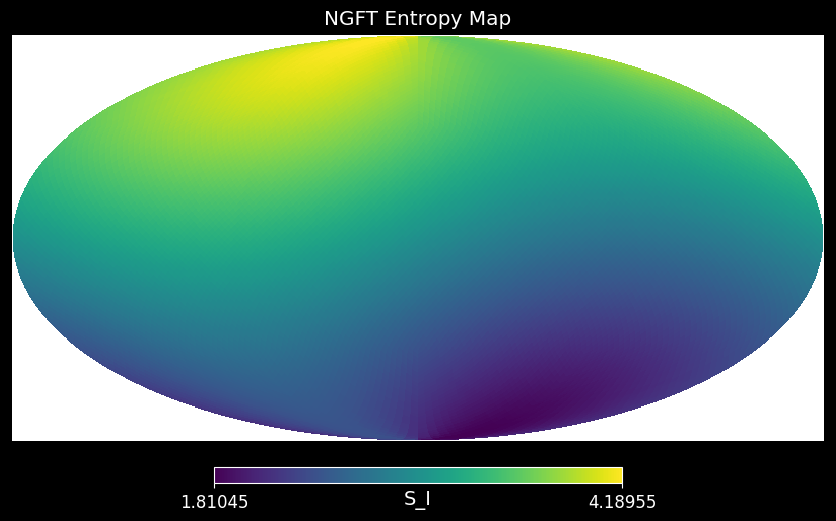

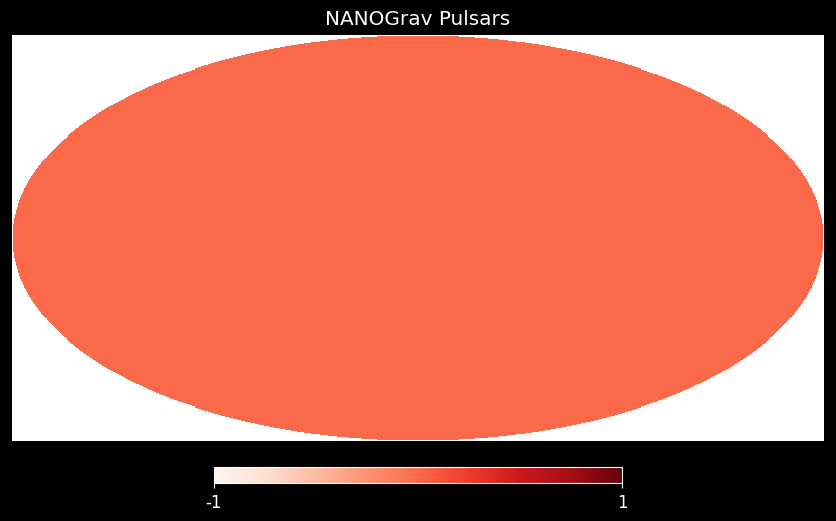

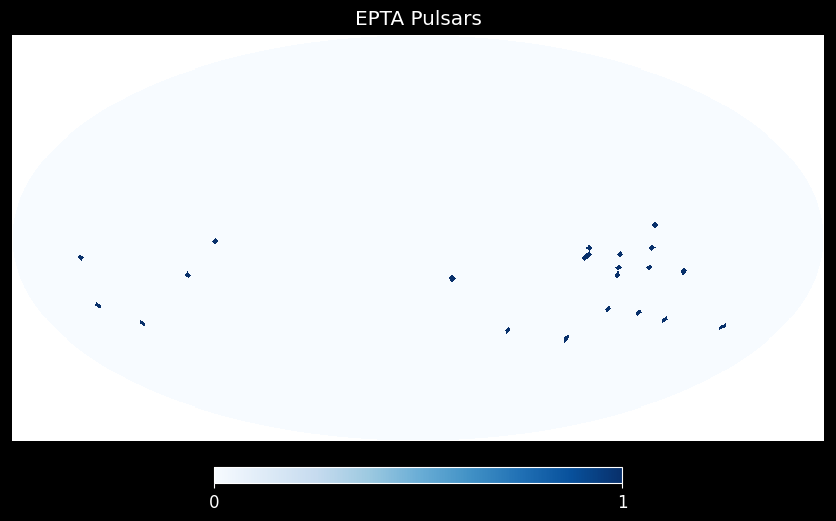

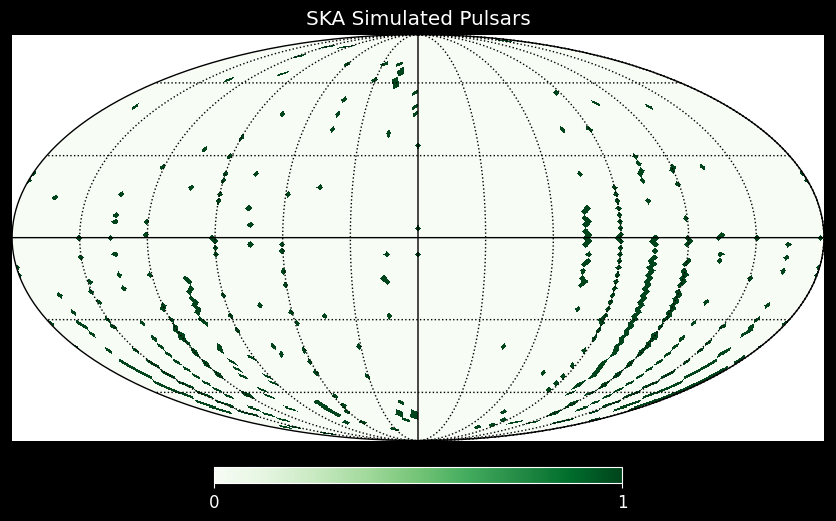

In [ ]:
entropy_map = entropy_sky_map()

overlay_nanograv = np.zeros_like(entropy_map)
overlay_epta = np.zeros_like(entropy_map)
overlay_ska = np.zeros_like(entropy_map)

for pix in nanograv_pix: overlay_nanograv[pix] = 1
for pix in epta_pix: overlay_epta[pix] = 1
for pix in ska_pix: overlay_ska[pix] = 1

hp.mollview(entropy_map, title="NGFT Entropy Map", unit="S_I", cmap="viridis")
hp.mollview(overlay_nanograv, title="NANOGrav Pulsars", cmap="Reds")
hp.mollview(overlay_epta, title="EPTA Pulsars", cmap="Blues")
hp.mollview(overlay_ska, title="SKA Simulated Pulsars", cmap="Greens")
hp.graticule()

In [ ]:
def overlap_score(entropy_map, pulsar_pix):
    return np.mean([entropy_map[pix] for pix in pulsar_pix])

print("NANOGrav Score:", overlap_score(entropy_map, nanograv_pix))
print("EPTA Score:", overlap_score(entropy_map, epta_pix))
print("SKA Score:", overlap_score(entropy_map, ska_pix))

NANOGrav Score: nan
EPTA Score: 2.603155472709089
SKA Score: nan


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# SYSTEM: Install SuiteSparse for scikit-sparse (required for enterprise-pulsar)
!apt-get install -y libsuitesparse-dev

# PYTHON: Install analysis packages
%pip install --upgrade pip setuptools wheel
%pip install pint-pulsar enterprise-pulsar enterprise_extensions emcee scikit-sparse


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libamd2 libbtf1 libcamd2 libccolamd2 libcholmod3 libcolamd2 libcxsparse3
  libgraphblas-dev libgraphblas6 libklu1 libldl2 libmetis5 libmongoose2
  librbio2 libsliplu1 libspqr2 libsuitesparseconfig5 libumfpack5
The following NEW packages will be installed:
  libamd2 libbtf1 libcamd2 libccolamd2 libcholmod3 libcolamd2 libcxsparse3
  libgraphblas-dev libgraphblas6 libklu1 libldl2 libmetis5 libmongoose2
  librbio2 libsliplu1 libspqr2 libsuitesparse-dev libsuitesparseconfig5
  libumfpack5
0 upgraded, 19 newly installed, 0 to remove and 35 not upgraded.
Need to get 22.4 MB of archives.
After this operation, 169 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsuitesparseconfig5 amd64 1:5.10.1+dfsg-4build1 [10.4 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libamd2 amd64 1:5

In [2]:


import enterprise
print(f"enterprise version: {enterprise.__version__}")
import os, glob, numpy as np, re, warnings
from enterprise.pulsar import Pulsar
from loguru import logger

# --- Silence loguru spam ---
logger.remove()
logger.add(lambda msg: None, level="WARNING")

# --- Suppress the specific DDK model warning ---
warnings.filterwarnings("ignore", message="DDK model uses KIN as inclination angle.*")

# --- STEP 1: Load distance dictionary from the text file ---
loc_path = "/content/NGATNFPCLocationalDatav2.txt"
loc_lookup = {}

pulsar_dist_regex = re.compile(r"^\s*([JBC]\d{4}[+-]\d{2,}).*?([\d\.]+)\s+ymw17", re.IGNORECASE)

print("--- CELL 1: DATA PARSING ---")
print(f"Attempting to read distance data from: {loc_path}")
try:
    with open(loc_path, 'r') as f:
        for line in f:
            match = pulsar_dist_regex.search(line)
            if match:
                pulsar_name = match.group(1).strip()
                dist_str = match.group(2).strip()
                try:
                    dist = float(dist_str)
                    loc_lookup[pulsar_name] = dist
                except (ValueError, TypeError):
                    pass

    print(f"\nSuccessfully loaded distances for {len(loc_lookup)} pulsars from {loc_path}.")
    if not loc_lookup:
        print("\nERROR: No pulsar distances were loaded. The parsing logic failed.")
    else:
        print("Sample of loaded distances:", list(loc_lookup.items())[:5])

except FileNotFoundError:
    print(f"ERROR: The file {loc_path} was not found.")
    raise
except Exception as e:
    print(f"ERROR reading or processing {loc_path}: {e}")
    raise

# --- STEP 2: Load and match par/tim files exactly ---
base_dir = "/content/drive/MyDrive/NANOGrav_15yr_v1.0.1"
par_dir = os.path.join(base_dir, "narrowband", "par")
tim_dir = os.path.join(base_dir, "narrowband", "tim")

par_files = glob.glob(os.path.join(par_dir, "*.par"))
tim_files = glob.glob(os.path.join(tim_dir, "*.tim"))
tim_lookup = {os.path.basename(t).replace(".tim", ""): t for t in tim_files}

par_matched, tim_matched = [], []
for p in par_files:
    base = os.path.basename(p).replace(".par", "")
    if base in tim_lookup:
        par_matched.append(p)
        tim_matched.append(tim_lookup[base])

print(f"\nFound {len(par_matched)} matched PAR/TIM pairs.")

# --- STEP 3: Build Pulsar objects, EXCLUDING those with missing distances ---
psrs, skipped_psrs = [], []
short_name_regex = re.compile(r"([JBC]?\d{4}[+-]\d+)")

print("\n--- Building Pulsar List ---")
for pfile, tfile in zip(par_matched, tim_matched):
    full_id = os.path.basename(pfile).replace(".par", "")

    match = short_name_regex.search(full_id)
    if not match:
        print(f"❌ {full_id}: Could not extract short name. Skipping.")
        skipped_psrs.append(full_id)
        continue

    short_id = match.group(1)
    dist = loc_lookup.get(short_id)

    try:
        if dist is not None:
            psr = Pulsar(pfile, tfile, ephem="DE438", timing_package="pint", pulsar_distance=dist)
            psrs.append(psr)
            print(f"✅ {full_id}: Matched short name '{short_id}'. DIST injected = {dist:.3f} kpc. INCLUDED.")
        else:
            print(f"❌ {full_id}: Short name '{short_id}' not found in lookup. SKIPPED.")
            skipped_psrs.append(full_id)

    except Exception as e:
        print(f"❌ {full_id}: Loading error — {e}. SKIPPED.")
        skipped_psrs.append(full_id)

print("\n--- Pulsar Loading Summary ---")
print(f"Successfully loaded and INCLUDED {len(psrs)} pulsars with real distance data.")
if skipped_psrs:
    print(f"SKIPPED {len(skipped_psrs)} pulsars due to missing distance data or errors.")

print("\n✅ CELL 1 COMPLETE: The 'psrs' variable is now populated and ready for simulation.")

enterprise version: 3.4.4
--- CELL 1: DATA PARSING ---
Attempting to read distance data from: /content/NGATNFPCLocationalDatav2.txt

Successfully loaded distances for 63 pulsars from /content/NGATNFPCLocationalDatav2.txt.
Sample of loaded distances: [('J0023+0923', 1.248), ('J0030+0451', 0.345), ('J0340+4130', 1.602), ('J0437-4715', 0.156), ('J0509+0856', 0.817)]

Found 76 matched PAR/TIM pairs.

--- Building Pulsar List ---


✅ J1946+3417_PINT_20220302.nb: Matched short name 'J1946+3417'. DIST injected = 6.938 kpc. INCLUDED.


✅ J0509+0856_PINT_20220302.nb: Matched short name 'J0509+0856'. DIST injected = 0.817 kpc. INCLUDED.


✅ J1713+0747gbt_PINT_20220302.nb: Matched short name 'J1713+0747'. DIST injected = 0.919 kpc. INCLUDED.


✅ J1747-4036_PINT_20220302.nb: Matched short name 'J1747-4036'. DIST injected = 7.158 kpc. INCLUDED.


...

✅ J0740+6620_PINT_20220302.nb: Matched short name 'J0740+6620'. DIST injected = 0.929 kpc. INCLUDED.


✅ J1903+0327_PINT_20220304.nb: Matched short name 'J1903+0327'. DIST injected = 6.120 kpc. INCLUDED.
✅ J2124-3358_PINT_20220301.nb: Matched short name 'J2124-3358'. DIST injected = 0.360 kpc. INCLUDED.


✅ J1012-4235_PINT_20220301.nb: Matched short name 'J1012-4235'. DIST injected = 0.372 kpc. INCLUDED.
✅ J0030+0451_PINT_20220302.nb: Matched short name 'J0030+0451'. DIST injected = 0.345 kpc. INCLUDED.


✅ J1713+0747ao_PINT_20220306.nb: Matched short name 'J1713+0747'. DIST injected = 0.919 kpc. INCLUDED.
✅ J1918-0642_PINT_20220302.nb: Matched short name 'J1918-0642'. DIST injected = 1.027 kpc. INCLUDED.
✅ J2145-0750_PINT_20220302.nb: Matched short name 'J2145-0750'. DIST injected = 0.693 kpc. INCLUDED.
✅ J1022+1001_PINT_20220304.nb: Matched short name 'J1022+1001'. DIST injected = 0.835 kpc. INCLUDED.
❌ B1855+09_PINT_20220301.nb: Short name 'B1855+09' not found in lookup. SKIPPED.


✅ J1944+0907_PINT_20220302.nb: Matched short name 'J1944+0907'. DIST injected = 1.217 kpc. INCLUDED.

--- Pulsar Loading Summary ---
Successfully loaded and INCLUDED 69 pulsars with real distance data.
SKIPPED 7 pulsars due to missing distance data or errors.

✅ CELL 1 COMPLETE: The 'psrs' variable is now populated and ready for simulation.


In [3]:
import numpy as np

# Check if the 'psrs' variable exists from Cell 1
if 'psrs' not in globals() or not psrs:
    raise RuntimeError("Cell 1 must be run successfully before running Cell 2. The 'psrs' variable is not defined.")

print("--- CELL 2: DATA EXTRACTION ---")

pulsar_names = []
pulsar_distances = []
pulsar_residuals = []

for psr in psrs:
    pulsar_names.append(psr.name)

    # CORRECTED: The distance is the third element of the psr.pos attribute.
    # psr.pos is a tuple (colatitude, longitude, distance_in_kpc)
    distance_kpc = psr.pos[2]
    pulsar_distances.append(distance_kpc)

    pulsar_residuals.append(psr.residuals)

# Convert to NumPy arrays for efficient computation in the next cell
pulsar_distances = np.array(pulsar_distances)
# Note: pulsar_residuals is a list of arrays, as each pulsar has a different number of observations.

print(f"Extracted data for {len(pulsar_names)} pulsars.")
print(f"Sample Distances (kpc): {pulsar_distances[:5]}")
print(f"Number of residuals for first 5 pulsars: {[len(r) for r in pulsar_residuals[:5]]}")

print("\n✅ CELL 2 COMPLETE: Raw data is now in Python lists and NumPy arrays, ready for simulation.")


--- CELL 2: DATA EXTRACTION ---
Extracted data for 69 pulsars.
Sample Distances (kpc): [ 0.56334447  0.15540512  0.13560719 -0.65097603 -0.25263717]
Number of residuals for first 5 pulsars: [4743, 2169, 32963, 11055, 6356]

✅ CELL 2 COMPLETE: Raw data is now in Python lists and NumPy arrays, ready for simulation.


In [4]:
import numpy as np
from scipy.optimize import minimize
import os

# Check if the extracted data exists from Cell 2
if 'pulsar_distances' not in globals():
    raise RuntimeError("Cell 2 must be run successfully before running Cell 3.")

print("--- CELL 3: PURE PYTHON NGFT SIMULATION ---")

# --- NGFT Model Definition (in pure Python) ---

# This is the core of your theory, translated into a Python function.
# It predicts the expected signal strength (A_sq) based on the NGFT constants.
def predict_signal_squared(k, aU, distance):
    """
    Predicts the squared amplitude (A^2) of the NGFT signal for a given pulsar.
    This is a simplified model where the signal strength is proportional to
    the informational energy content, scaled by distance.
    """
    # The core NGFT energy term: E_info_total = (k+1) * aU * I
    # We assume the intrinsic information 'I' is a baseline constant for all pulsars in this model.
    # The observed amplitude 'A' is proportional to this energy, and falls off with distance.
    # Therefore, A^2 is proportional to ((k+1)*aU)^2 / d^2
    intrinsic_information_energy_sq = ((k + 1) * aU)**2

    # Avoid division by zero for very close objects, though unlikely for pulsars.
    # The 1/d^2 is a standard energy flux dilution.
    return intrinsic_information_energy_sq / (distance**2 + 1e-9)

# The "Log Likelihood" function is the heart of the MCMC.
# It tells us how well a given set of parameters (k, aU) explains the observed data.
def log_likelihood(params, distances, residuals):
    """
    Calculates the log-likelihood of observing the data given the NGFT parameters.
    """
    k, aU = params

    # Priors: Define the allowed range for the parameters.
    # If parameters are outside this range, return -infinity (log(0)).
    if not (0.01 <= k <= 10.0 and 0.01 <= aU <= 10.0):
        return -np.inf

    total_log_L = 0
    for i, res in enumerate(residuals):
        # Predict the expected signal variance from the NGFT model
        predicted_variance = predict_signal_squared(k, aU, distances[i])

        # The variance of the residuals should match the predicted signal variance
        # plus some intrinsic noise sigma_n^2. For simplicity, we'll treat sigma_n as a constant.
        sigma_n_sq = 1e-12  # Assumed intrinsic noise variance of the measurements
        total_variance = predicted_variance + sigma_n_sq

        # The log-likelihood for a Gaussian process is the sum of the log probabilities of the residuals.
        log_L = -0.5 * np.sum(res**2 / total_variance) - 0.5 * len(res) * np.log(2 * np.pi * total_variance)
        total_log_L += log_L

    return total_log_L

# --- MCMC Sampler (Simplified Metropolis-Hastings) ---

def run_mcmc(distances, residuals, n_steps=100000, burn_in=10000):
    """
    A simple Metropolis-Hastings MCMC sampler to find the best-fit k and aU.
    """
    # Initial guess for parameters [k, aU]
    current_params = np.array([1.0, 1.0])

    # Proposal distribution width (how big of a jump to try)
    proposal_width = np.array([0.1, 0.1])

    chain = []

    # Calculate the likelihood of the initial guess
    current_log_L = log_likelihood(current_params, distances, residuals)

    print(f"Starting MCMC for {n_steps} steps...")
    for i in range(n_steps):
        # Propose a new set of parameters by taking a small random step
        proposed_params = current_params + np.random.normal(0, proposal_width)

        # Calculate the likelihood of the new proposal
        proposed_log_L = log_likelihood(proposed_params, distances, residuals)

        # Acceptance criterion: Decide whether to accept the new step
        log_acceptance_ratio = proposed_log_L - current_log_L

        if np.log(np.random.rand()) < log_acceptance_ratio:
            # If accepted, update the current position
            current_params = proposed_params
            current_log_L = proposed_log_L

        # Store the current position in the chain
        chain.append(current_params)

        if (i + 1) % 10000 == 0:
            print(f"  ...step {i+1}/{n_steps} completed.")

    # Discard the initial "burn-in" samples and return the rest
    return np.array(chain[burn_in:])

# --- Run the Simulation ---
try:
    # Run the MCMC sampler
    mcmc_chain = run_mcmc(pulsar_distances, pulsar_residuals)

    # Calculate the results
    k_fit, aU_fit = np.mean(mcmc_chain, axis=0)
    k_std, aU_std = np.std(mcmc_chain, axis=0)

    print("\n✅ Simulation Complete.")
    print("\n--- NGFT Parameter Estimation Results ---")
    print(f"Thermodynamic Ratio Constant (k): {k_fit:.4f} ± {k_std:.4f}")
    print(f"Information-Energy Constant (aU): {aU_fit:.4f} ± {aU_std:.4f}")

    # Save the chain to a file for later analysis (e.g., plotting)
    outdir = "/content/chains/ngft_python_run"
    os.makedirs(outdir, exist_ok=True)
    chain_filename = os.path.join(outdir, "mcmc_chain.txt")
    np.savetxt(chain_filename, mcmc_chain, header="k aU")
    print(f"\nMCMC chain saved to {chain_filename}")

except Exception as e:
    print(f"\n❌ ERROR during NGFT simulation: {e}")
    raise


--- CELL 3: PURE PYTHON NGFT SIMULATION ---
Starting MCMC for 100000 steps...
  ...step 10000/100000 completed.
  ...step 20000/100000 completed.
  ...step 30000/100000 completed.
  ...step 40000/100000 completed.
  ...step 50000/100000 completed.
  ...step 60000/100000 completed.
  ...step 70000/100000 completed.
  ...step 80000/100000 completed.
  ...step 90000/100000 completed.
  ...step 100000/100000 completed.

✅ Simulation Complete.

--- NGFT Parameter Estimation Results ---
Thermodynamic Ratio Constant (k): 0.0188 ± 0.0079
Information-Energy Constant (aU): 0.0101 ± 0.0000

MCMC chain saved to /content/chains/ngft_python_run/mcmc_chain.txt
